# Laboratorio 4

In [7]:

import rasterio
import numpy as np
import matplotlib.pyplot as plt
from datetime import date
import openeo

### Ejercicio 1 

Establezca una conexión con la api de sentinel 2, puede usar para eso el módulo openeo.


In [8]:
connection = openeo.connect("https://openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


### Ejercicio 2

Descarga los .tif de cada uno de los lagos usando para eso las coordenadas o el geojson provisto


In [11]:
import json

with open("./archive/Lago_Amatitlan.geojson", "r", encoding="utf-8") as archivo:
    amatitlan = json.load(archivo)

with open("./archive/Lago_Atitlan.geojson", "r", encoding="utf-8") as archivo:
    atitlan = json.load(archivo)


print("Amatitlan, ", amatitlan)
print("Atitlan, ", atitlan)

Amatitlan,  {'type': 'FeatureCollection', 'name': 'Lago_Amatitlan', 'crs': {'type': 'name', 'properties': {'name': 'urn:ogc:def:crs:OGC:1.3:CRS84'}}, 'features': [{'type': 'Feature', 'properties': {'name': 'Lago Amatitlán'}, 'geometry': {'type': 'Polygon', 'coordinates': [[[-90.512924, 14.412347], [-90.512924, 14.493799], [-90.638065, 14.493799], [-90.638065, 14.412347], [-90.512924, 14.412347]]]}}]}
Atitlan,  {'type': 'FeatureCollection', 'name': 'Lago_Atitlan', 'crs': {'type': 'name', 'properties': {'name': 'urn:ogc:def:crs:OGC:1.3:CRS84'}}, 'features': [{'type': 'Feature', 'properties': {'name': 'Lago Atitlán'}, 'geometry': {'type': 'Polygon', 'coordinates': [[[-91.07151, 14.5948], [-91.07151, 14.750979], [-91.326256, 14.750979], [-91.326256, 14.5948], [-91.07151, 14.5948]]]}}]}


In [12]:
geometry_atl = atitlan["features"][0]["geometry"]["coordinates"][0]

longitudes_atl = [punto[0] for punto in geometry_atl]
latitudes_atl = [punto[1] for punto in geometry_atl]

crd_atl = {
  "west": min(longitudes_atl),
    "east": max(longitudes_atl),
    "south": min(latitudes_atl),
    "north": max(latitudes_atl)
}

  

Cargando los datos en cubes

In [21]:

atitlan_cube = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=crd_atl,
    temporal_extent=["2025-01-01", "2025-08-01"],
    bands=["B02", "B03", "B04", "B05", "B07", "B08", "B8A", "B11", "B12"]

)

El problema es que esto descarga por dia, lo haremos 2 por mes

In [22]:
result_graph = atitlan_cube.save_result(format="GTIFF")
job = connection.create_job(result_graph)

# Iniciar y esperar que termine
job.start_and_wait()

# Obtener resultados y descargarlos a carpeta
results = job.get_results()
results.download_files("./data/GIS/Atitlan")

print("Descarga finalizada.")

# Verificar archivos descargados
import os

folder = "./data/GIS/Atitlan"
files = os.listdir(folder)
for f in files:
    size = os.path.getsize(os.path.join(folder, f))
    print(f"{f} - {size} bytes")

# Imprimir logs del job por si hubo errores



0:00:00 Job 'j-2508080644294b6394144dac74d0afc5': send 'start'
0:00:13 Job 'j-2508080644294b6394144dac74d0afc5': created (progress 0%)
0:00:18 Job 'j-2508080644294b6394144dac74d0afc5': created (progress 0%)
0:00:25 Job 'j-2508080644294b6394144dac74d0afc5': created (progress 0%)
0:00:33 Job 'j-2508080644294b6394144dac74d0afc5': created (progress 0%)
0:00:43 Job 'j-2508080644294b6394144dac74d0afc5': running (progress N/A)
0:00:55 Job 'j-2508080644294b6394144dac74d0afc5': running (progress N/A)
0:01:11 Job 'j-2508080644294b6394144dac74d0afc5': running (progress N/A)
0:01:31 Job 'j-2508080644294b6394144dac74d0afc5': running (progress N/A)
0:01:55 Job 'j-2508080644294b6394144dac74d0afc5': running (progress N/A)
0:02:25 Job 'j-2508080644294b6394144dac74d0afc5': running (progress N/A)
0:03:03 Job 'j-2508080644294b6394144dac74d0afc5': running (progress N/A)
0:03:49 Job 'j-2508080644294b6394144dac74d0afc5': running (progress N/A)
0:04:48 Job 'j-2508080644294b6394144dac74d0afc5': running (progre

Ahora amatitlan

In [23]:
geometry_aml = amatitlan["features"][0]["geometry"]["coordinates"][0]

longitudes_aml = [punto[0] for punto in geometry_aml]
latitudes_aml = [punto[1] for punto in geometry_aml]

crd_aml = {
  "west": min(longitudes_aml),
    "east": max(longitudes_aml),
    "south": min(latitudes_aml),
    "north": max(latitudes_aml)
}

  

## Ejercicio 3

In [24]:

amatitlan_cube = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=crd_aml,
    temporal_extent=["2025-01-01", "2025-08-01"],
    bands=["B02", "B03", "B04", "B05", "B07", "B08", "B8A", "B11", "B12"]
)

In [25]:
result_graph = amatitlan_cube.save_result(format="GTIFF")
job = connection.create_job(result_graph)

# Iniciar y esperar que termine
job.start_and_wait()

# Obtener resultados y descargarlos a carpeta
results = job.get_results()
results.download_files("./data/GIS/Amatitlan")

print("Descarga finalizada.")

# Verificar archivos descargados
import os

folder = "./data/GIS/Amatitlan"
files = os.listdir(folder)
for f in files:
    size = os.path.getsize(os.path.join(folder, f))
    print(f"{f} - {size} bytes")



0:00:00 Job 'j-2508080841514ad09f034b81ee7a08df': send 'start'
0:00:13 Job 'j-2508080841514ad09f034b81ee7a08df': created (progress 0%)
0:00:19 Job 'j-2508080841514ad09f034b81ee7a08df': queued (progress 0%)
0:00:25 Job 'j-2508080841514ad09f034b81ee7a08df': queued (progress 0%)
0:00:33 Job 'j-2508080841514ad09f034b81ee7a08df': queued (progress 0%)
0:00:43 Job 'j-2508080841514ad09f034b81ee7a08df': queued (progress 0%)
0:00:57 Job 'j-2508080841514ad09f034b81ee7a08df': queued (progress 0%)
0:01:13 Job 'j-2508080841514ad09f034b81ee7a08df': queued (progress 0%)
0:01:32 Job 'j-2508080841514ad09f034b81ee7a08df': running (progress N/A)
0:01:56 Job 'j-2508080841514ad09f034b81ee7a08df': running (progress N/A)
0:02:26 Job 'j-2508080841514ad09f034b81ee7a08df': running (progress N/A)
0:03:04 Job 'j-2508080841514ad09f034b81ee7a08df': running (progress N/A)
0:03:51 Job 'j-2508080841514ad09f034b81ee7a08df': running (progress N/A)
0:04:49 Job 'j-2508080841514ad09f034b81ee7a08df': running (progress N/A)
0

## Ejercicio 4

In [8]:
import os
import re
from pathlib import Path
import numpy as np
import rasterio

# Fechas válidas
clear_dates = {
    "2025-02-07","2025-02-10","2025-02-25","2025-02-27",
    "2025-03-02","2025-03-04","2025-03-07","2025-03-09",
    "2025-03-12","2025-03-14","2025-03-19","2025-03-22",
    "2025-03-24","2025-03-26","2025-04-03","2025-04-11",
    "2025-04-13","2025-04-15","2025-04-16","2025-04-18",
    "2025-04-28","2025-05-03","2025-05-13","2025-05-28",
    "2025-07-10","2025-07-17","2025-07-20","2025-07-24",
    "2025-08-01"
}

def parse_date_from_name(name):
    m = re.search(r"openEO_(\d{4}-\d{2}-\d{2})Z", name)
    return m.group(1) if m else None

def compute_index(num, den):
    with np.errstate(divide="ignore", invalid="ignore"):
        return np.where(den == 0, np.nan, num / den)

def normalize_if_needed(x):
    x = x.astype(np.float32)
    return x / 10000.0 if np.nanmax(x) > 2 else x

def _try_find_band_index_by_description(src, candidates=("B05", "705")):
    """
    Intenta ubicar el índice (1-based) de B05 buscando en descriptions o tags.
    Devuelve None si no encuentra.
    """
    # descriptions suele tener nombre tipo "B04", "B05", etc.
    if src.descriptions and any(src.descriptions):
        for i, desc in enumerate(src.descriptions, start=1):
            if not desc:
                continue
            d = desc.upper()
            if any(c in d for c in (c.upper() for c in candidates)):
                return i
    # fallback: buscar en tags por banda
    for i in range(1, src.count + 1):
        tags = src.tags(i)
        for v in tags.values():
            d = str(v).upper()
            if any(c in d for c in (c.upper() for c in candidates)):
                return i
    return None

def process_all_images(DATA_DIR, band_map=None):
    """
    Recorre todos los .tif en DATA_DIR y devuelve tres diccionarios:
    ndvi_data, ndwi_data, ndci_data (este último puede tener None si no hay B05).

    band_map (opcional) permite forzar el índice 1-based de cada banda:
        {"GREEN":1, "RED":2, "NIR":3, "SWIR":4, "B05":3}
    Ajusta según el orden real de tu stack.
    """
    ndvi_data, ndwi_data, ndci_data = {}, {}, {}

    for tif_path in Path(DATA_DIR).glob("openEO_*Z*.tif"):
        date = parse_date_from_name(tif_path.name)
        if not date or date not in clear_dates:
            continue

        with rasterio.open(tif_path) as src:
            # Detectar bandas
            if band_map is None:
                # Suponemos tu orden original:
                # 1=GREEN(B03), 2=RED(B04), 3=NIR(B08), 4=SWIR(B11)
                idx_green = 1
                idx_red   = 2
                idx_nir   = 3
                idx_swir  = 4
                # Intentar encontrar B05 por descripción (si existe en el stack)
                idx_b05 = _try_find_band_index_by_description(src, candidates=("B05", "705"))
            else:
                idx_green = band_map.get("GREEN")
                idx_red   = band_map.get("RED")
                idx_nir   = band_map.get("NIR")
                idx_swir  = band_map.get("SWIR")
                idx_b05   = band_map.get("B05") 

            green = normalize_if_needed(src.read(idx_green))
            red   = normalize_if_needed(src.read(idx_red))
            nir   = normalize_if_needed(src.read(idx_nir))

            # Índices
            ndvi = compute_index(nir - red,   nir + red)      # NDVI
            ndwi = compute_index(green - nir, green + nir)    # NDWI (McFeeters)

            # NDCI (si hallamos B05)
            ndci = None
            if idx_b05 is not None:
                b05 = normalize_if_needed(src.read(idx_b05))
                ndci = compute_index(b05 - red, b05 + red)
            else:
                # Si quieres que sea obligatorio, cambia a raise
                print(f"[AVISO] {tif_path.name}: no se encontró B05 → NDCI omitido.")

            ndvi_data[date] = ndvi
            ndwi_data[date] = ndwi
            ndci_data[date] = ndci  # puede ser None

    return ndvi_data, ndwi_data, ndci_data

# --- Usa la función para ambos lagos ---
DATA_DIR = "./data/GIS/Atitlan"
AMA_DIR  = "./data/GIS/Amatitlan"

atitlan_ndvi, atitlan_ndwi, atitlan_ndci = process_all_images(DATA_DIR)
amatitlan_ndvi, amatitlan_ndwi, amatitlan_ndci = process_all_images(AMA_DIR)

print("Atitlán:", len(atitlan_ndvi), "fechas NDVI,", sum(v is not None for v in atitlan_ndci.values()), "con NDCI")
print("Amatitlán:", len(amatitlan_ndvi), "fechas NDVI,", sum(v is not None for v in amatitlan_ndci.values()), "con NDCI")





Atitlán: 28 fechas NDVI, 28 con NDCI
Amatitlán: 18 fechas NDVI, 18 con NDCI


## Ejercicio 5 y 6

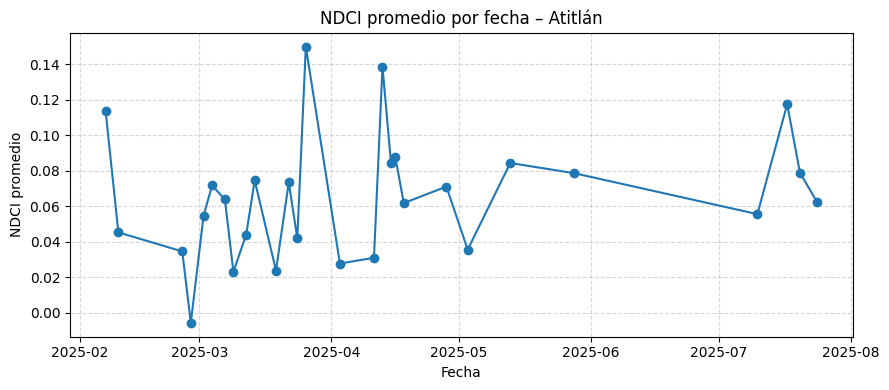

Listo: ndci_mean_timeseries.csv y ndci_mean_timeseries.png generados.


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def series_y_grafico(index_dict, titulo, y_label, csv_out, png_out, clip_min=-1.0, clip_max=1.0):
    """
    index_dict: dict { 'YYYY-MM-DD': ndarray2D | None }
    titulo:     str  título del gráfico
    y_label:    str  etiqueta del eje Y
    csv_out:    str  ruta del CSV a guardar
    png_out:    str  ruta del PNG a guardar
    clip_min/max:    límites para recortar valores extremos antes de promediar
    """
    rows = []
    for d, arr in index_dict.items():
        if arr is None:
            # p. ej., NDCI ausente si no hubo B05 para esa fecha
            continue
        arr_clip = np.clip(arr.astype(np.float32), clip_min, clip_max)
        rows.append({"date": pd.to_datetime(d), "mean": np.nanmean(arr_clip)})

    if not rows:
        raise ValueError("No hay datos válidos para construir la serie.")

    df = (pd.DataFrame(rows)
            .sort_values("date")
            .set_index("date"))

    # Guardar CSV
    df.to_csv(csv_out)

    # Graficar
    plt.figure(figsize=(9,4))
    plt.plot(df.index, df["mean"], marker="o")
    plt.title(titulo)
    plt.xlabel("Fecha")
    plt.ylabel(y_label)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig(png_out, dpi=150)
    plt.show()

    print(f"Listo: {csv_out} y {png_out} generados.")
    return df  # por si quieres reutilizar la serie en más análisis


ndci_df = series_y_grafico(
    atitlan_ndci,
    "NDCI promedio por fecha – Atitlán",
    "NDCI promedio",
    "ndci_mean_timeseries.csv",
    "ndci_mean_timeseries.png",
    clip_min=-0.5, clip_max=0.8  # ejemplo
)


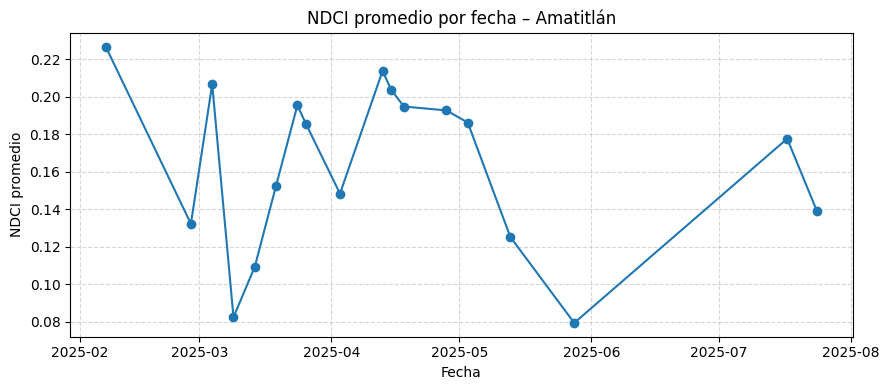

Listo: ndci_mean_timeseries_amatitlan.csv y ndci_mean_timeseries_amatitlan.png generados.


In [10]:
ndci_df2 = series_y_grafico(
    amatitlan_ndci,
    "NDCI promedio por fecha – Amatitlán",
    "NDCI promedio",
    "ndci_mean_timeseries_amatitlan.csv",
    "ndci_mean_timeseries_amatitlan.png",
    clip_min=-0.5, clip_max=0.8  # ejemplo
)

Podemos ver que las fechas criticas en ambos lagos son en abril y mayo en donde la cianobacteria se ve que tienen una mayor floracion, esto talvez debido a que en esas fechas suelen haber mas plorifelacion de nutrientes en el agua debido a las corrientes generadas en epocas de lluvia . 

## Ejercicio 7

### Mapa Iterativo

Vamos a crear el mapa interactivo para que podamos observar como se ve en el lago la distribucion de la cianobacteria

In [3]:
import os
import re
from pathlib import Path
import tempfile
import numpy as np
import rasterio
from rasterio.warp import transform_bounds
import matplotlib.pyplot as plt
from matplotlib import cm
from PIL import Image
import folium
from folium.plugins import TimestampedGeoJson
import datetime
import base64
import io
import json

# --- parámetros ---
CLEAR_DATES = {
    "2025-02-07","2025-02-10","2025-02-25","2025-02-27",
    "2025-03-02","2025-03-04","2025-03-07","2025-03-09",
    "2025-03-12","2025-03-14","2025-03-19","2025-03-22",
    "2025-03-24","2025-03-26","2025-04-03","2025-04-11",
    "2025-04-13","2025-04-15","2025-04-16","2025-04-18",
    "2025-04-28","2025-05-03","2025-05-13","2025-05-28",
    "2025-07-10","2025-07-17","2025-07-20","2025-07-24",
    "2025-08-01"
}
CLIP_MIN, CLIP_MAX = -0.5, 0.8

def parse_date_from_name(name):
    m = re.search(r"openEO_(\d{4}-\d{2}-\d{2})Z", name)
    return m.group(1) if m else None

def normalize_if_needed(x):
    x = x.astype(np.float32)
    return x / 10000.0 if np.nanmax(x) > 2 else x

def compute_index(num, den):
    with np.errstate(divide="ignore", invalid="ignore"):
        return np.where(den == 0, np.nan, num / den)

def _try_find_band_index_by_description(src, candidates=("B05","705")):
    if getattr(src, "descriptions", None):
        for i, desc in enumerate(src.descriptions, start=1):
            if desc and any(c.upper() in desc.upper() for c in candidates):
                return i
    for i in range(1, src.count + 1):
        for v in src.tags(i).values():
            if v and any(c.upper() in str(v).upper() for c in candidates):
                return i
    return None

def ndci_to_png_base64(ndci, clip_min=CLIP_MIN, clip_max=CLIP_MAX, cmap_name="viridis"):
    """Convierte NDCI a imagen PNG en base64 con transparencia para NaN"""
    arr = np.clip(ndci, clip_min, clip_max)
    norm = (arr - clip_min) / (clip_max - clip_min)
    
    # Aplicar colormap
    cmap = cm.get_cmap(cmap_name)
    rgba = (cmap(norm) * 255).astype(np.uint8)
    
    # Hacer transparentes los valores NaN
    mask_nan = np.isnan(ndci)
    rgba[mask_nan, 3] = 0  # Alpha = 0 para transparencia
    
    # Crear imagen PIL
    img = Image.fromarray(rgba, mode='RGBA')
    
    # Convertir a base64
    buffer = io.BytesIO()
    img.save(buffer, format='PNG')
    img_base64 = base64.b64encode(buffer.getvalue()).decode('utf-8')
    
    return img_base64

def create_time_slider_ndci_map(DATA_DIR, out_html):
    """Crea mapa con slider temporal personalizado para evolución de cianobacterias"""
    
    # Coordenadas fijas del Lago Atitlán (Guatemala)
    LAGO_BOUNDS = {
        'west': -91.326256,
        'east': -91.07151,
        'south': 14.5948,
        'north': 14.750979
    }
    map_center = [(LAGO_BOUNDS['south'] + LAGO_BOUNDS['north']) / 2, 
                  (LAGO_BOUNDS['west'] + LAGO_BOUNDS['east']) / 2]
    
    image_data = []
    
    print("Procesando archivos TIFF...")
    
    # Procesar todas las imágenes
    for tif in sorted(Path(DATA_DIR).glob("openEO_*Z*.tif")):
        date_str = parse_date_from_name(tif.name)
        if date_str not in CLEAR_DATES:
            continue
            
        print(f"Procesando: {tif.name} - Fecha: {date_str}")
            
        with rasterio.open(tif) as src:
            idx_red = 2
            idx_b05 = _try_find_band_index_by_description(src, ("B05","705"))
            if idx_b05 is None:
                print(f"  ❌ No se encontró banda B05 en {tif.name}")
                continue

            red = normalize_if_needed(src.read(idx_red))
            b05 = normalize_if_needed(src.read(idx_b05))
            ndci = compute_index(b05 - red, b05 + red)
            
            if np.all(np.isnan(ndci)):
                print(f"  ❌ Todos los valores NDCI son NaN en {tif.name}")
                continue

            # Usar bounds fijos del Lago Atitlán para geolocalización correcta
            # (Los bounds del TIFF pueden estar mal georeferenciados)
            west = LAGO_BOUNDS['west']
            east = LAGO_BOUNDS['east'] 
            south = LAGO_BOUNDS['south']
            north = LAGO_BOUNDS['north']
            
            # Mostrar bounds originales del TIFF para debug
            orig_bounds = rasterio.transform.array_bounds(src.height, src.width, src.transform)
            if src.crs and src.crs.to_string() != "EPSG:4326":
                orig_west, orig_south, orig_east, orig_north = transform_bounds(src.crs, "EPSG:4326",
                                                                orig_bounds[1], orig_bounds[0],
                                                                orig_bounds[3], orig_bounds[2])
            else:
                orig_south, orig_west, orig_north, orig_east = orig_bounds[0], orig_bounds[1], orig_bounds[2], orig_bounds[3]
            
            print(f"  📍 Bounds originales TIFF: ({orig_west:.6f}, {orig_south:.6f}) a ({orig_east:.6f}, {orig_north:.6f})")
            print(f"  📍 Bounds corregidos Lago: ({west:.6f}, {south:.6f}) a ({east:.6f}, {north:.6f})")
            
            # Convertir NDCI a imagen base64
            img_b64 = ndci_to_png_base64(ndci)
            
            # Calcular estadísticas
            ndci_stats = {
                'min': float(np.nanmin(ndci)),
                'max': float(np.nanmax(ndci)),
                'mean': float(np.nanmean(ndci)),
                'std': float(np.nanstd(ndci))
            }
            
            image_data.append({
                'date': date_str,
                'bounds': [[south, west], [north, east]],
                'image': f"data:image/png;base64,{img_b64}",
                'stats': ndci_stats
            })
            
            print(f"  ✅ Procesado - NDCI medio: {ndci_stats['mean']:.3f}")
    
    if not image_data:
        print("❌ No se encontraron imágenes válidas para procesar")
        return None
    
    print(f"✅ Se procesaron {len(image_data)} imágenes válidas")
    
    # Ordenar por fecha
    image_data.sort(key=lambda x: x['date'])
    
    # Crear mapa base centrado en el Lago Atitlán
    m = folium.Map(
        location=map_center, 
        zoom_start=12,  # Zoom más cercano para el lago
        tiles="CartoDB Positron"
    )
    
    # Agregar polígono del Lago Atitlán como referencia
    lago_polygon = folium.Polygon(
        locations=[
            [14.5948, -91.07151],
            [14.750979, -91.07151], 
            [14.750979, -91.326256],
            [14.5948, -91.326256]
        ],
        color='blue',
        weight=2,
        fill=False,
        popup="Límites del Lago Atitlán"
    )
    lago_polygon.add_to(m)
    
    # Convertir datos a JSON para JavaScript
    js_data = json.dumps(image_data)
    
    # HTML y JavaScript personalizado para el slider
    slider_html = f'''
    <div id="time-slider-container" style="
        position: fixed; 
        bottom: 20px; 
        left: 50px; 
        right: 50px; 
        z-index: 1000; 
        background: rgba(255,255,255,0.9); 
        padding: 15px; 
        border-radius: 5px;
        box-shadow: 0 2px 10px rgba(0,0,0,0.3);
    ">
        <h4 style="margin: 0 0 10px 0; text-align: center;">Evolución de Cianobacterias (NDCI)</h4>
        <div style="display: flex; align-items: center; margin-bottom: 10px;">
            <button id="play-btn" style="margin-right: 10px; padding: 5px 10px;">▶️ Play</button>
            <input type="range" id="time-slider" min="0" max="{len(image_data)-1}" value="0" 
                   style="flex: 1; margin: 0 10px;">
            <span id="date-display" style="min-width: 100px; font-weight: bold;">{image_data[0]['date']}</span>
        </div>
        <div id="stats-display" style="font-size: 12px; text-align: center;">
            NDCI - Min: {image_data[0]['stats']['min']:.3f} | 
            Medio: {image_data[0]['stats']['mean']:.3f} | 
            Max: {image_data[0]['stats']['max']:.3f}
        </div>
    </div>

    <script>
    var imageData = {js_data};
    var currentOverlay = null;
    var isPlaying = false;
    var playInterval = null;
    
    function updateMap(index) {{
        var data = imageData[index];
        
        // Remover overlay anterior
        if (currentOverlay) {{
            map_{m._id}.removeLayer(currentOverlay);
        }}
        
        // Agregar nuevo overlay
        currentOverlay = L.imageOverlay(
            data.image,
            data.bounds,
            {{
                opacity: 0.8,
                interactive: false
            }}
        ).addTo(map_{m._id});
        
        // Actualizar displays
        document.getElementById('date-display').textContent = data.date;
        document.getElementById('stats-display').innerHTML = 
            'NDCI - Min: ' + data.stats.min.toFixed(3) + ' | ' +
            'Medio: ' + data.stats.mean.toFixed(3) + ' | ' +
            'Max: ' + data.stats.max.toFixed(3);
    }}
    
    // Event listeners
    document.getElementById('time-slider').addEventListener('input', function(e) {{
        updateMap(parseInt(e.target.value));
    }});
    
    document.getElementById('play-btn').addEventListener('click', function() {{
        if (!isPlaying) {{
            isPlaying = true;
            this.innerHTML = '⏸️ Pause';
            
            playInterval = setInterval(function() {{
                var slider = document.getElementById('time-slider');
                var currentVal = parseInt(slider.value);
                var maxVal = parseInt(slider.max);
                
                if (currentVal < maxVal) {{
                    slider.value = currentVal + 1;
                    updateMap(currentVal + 1);
                }} else {{
                    // Reiniciar al principio
                    slider.value = 0;
                    updateMap(0);
                }}
            }}, 1000); // Cambiar cada segundo
            
        }} else {{
            isPlaying = false;
            this.innerHTML = '▶️ Play';
            clearInterval(playInterval);
        }}
    }});
    
    // Inicializar con la primera imagen
    updateMap(0);
    </script>
    '''
    
    # Agregar leyenda de colores
    legend_html = f'''
    <div style="position: fixed; 
                top: 80px; right: 20px; width: 200px; height: 120px; 
                background-color: white; border:2px solid grey; z-index:9999; 
                font-size:12px; padding: 10px; border-radius: 5px;">
    <h4 style="margin: 0 0 10px 0;">Índice NDCI</h4>
    <div style="background: linear-gradient(to right, #440154, #31688e, #35b779, #fde725); 
                height: 20px; margin: 5px 0;"></div>
    <div style="display: flex; justify-content: space-between; font-size: 10px;">
        <span>{CLIP_MIN}</span>
        <span>0</span>
        <span>{CLIP_MAX}</span>
    </div>
    <p style="margin: 5px 0; font-size: 10px;">
        <strong>Valores altos:</strong> Mayor concentración de cianobacterias<br>
        <strong>Valores bajos:</strong> Menor concentración
    </p>
    </div>
    '''
    
    # Agregar HTML personalizado al mapa
    m.get_root().html.add_child(folium.Element(slider_html))
    m.get_root().html.add_child(folium.Element(legend_html))
    
    # Guardar mapa
    m.save(out_html)
    print(f"✅ Mapa guardado en {out_html}")
    print(f"📊 Fechas disponibles: {[d['date'] for d in image_data]}")
    
    return m

def create_simple_timestamped_geojson(DATA_DIR, out_html):
    """Versión simplificada usando TimestampedGeoJson con colores por estadísticas"""
    
    # Coordenadas fijas del Lago Atitlán
    LAGO_BOUNDS = {
        'west': -91.326256,
        'east': -91.07151,
        'south': 14.5948,
        'north': 14.750979
    }
    map_center = [(LAGO_BOUNDS['south'] + LAGO_BOUNDS['north']) / 2, 
                  (LAGO_BOUNDS['west'] + LAGO_BOUNDS['east']) / 2]
    
    features = []
    stats_data = []
    
    print("Procesando archivos para TimestampedGeoJson...")
    
    for tif in sorted(Path(DATA_DIR).glob("openEO_*Z*.tif")):
        date_str = parse_date_from_name(tif.name)
        if date_str not in CLEAR_DATES:
            continue
            
        with rasterio.open(tif) as src:
            idx_red = 2
            idx_b05 = _try_find_band_index_by_description(src, ("B05","705"))
            if idx_b05 is None:
                continue

            red = normalize_if_needed(src.read(idx_red))
            b05 = normalize_if_needed(src.read(idx_b05))
            ndci = compute_index(b05 - red, b05 + red)
            
            if np.all(np.isnan(ndci)):
                continue

            # Calcular estadística representativa
            ndci_mean = np.nanmean(ndci)
            ndci_max = np.nanmax(ndci)
            
            # Usar el valor máximo para representar "blooms" de cianobacterias
            representative_value = ndci_max
            
            # Mapear a color
            norm_val = (representative_value - CLIP_MIN) / (CLIP_MAX - CLIP_MIN)
            norm_val = np.clip(norm_val, 0, 1)
            
            cmap = cm.get_cmap('viridis')
            rgba = cmap(norm_val)
            color_hex = f"#{int(rgba[0]*255):02x}{int(rgba[1]*255):02x}{int(rgba[2]*255):02x}"

            # Usar bounds fijos del Lago Atitlán
            west = LAGO_BOUNDS['west']
            east = LAGO_BOUNDS['east'] 
            south = LAGO_BOUNDS['south']
            north = LAGO_BOUNDS['north']

            # Crear feature
            geometry = {
                "type": "Polygon",
                "coordinates": [[[west, south], [east, south], [east, north], [west, north], [west, south]]]
            }

            feature = {
                "type": "Feature",
                "geometry": geometry,
                "properties": {
                    "time": date_str,
                    "style": {
                        "fillColor": color_hex,
                        "color": "#333333",
                        "weight": 1,
                        "fillOpacity": 0.8
                    },
                    "popup": f"""
                    <b>🦠 Cianobacterias - {date_str}</b><br>
                    NDCI Medio: {ndci_mean:.3f}<br>
                    NDCI Máximo: {ndci_max:.3f}<br>
                    <small>Valores altos = Mayor concentración</small>
                    """
                }
            }
            features.append(feature)
            
            stats_data.append({
                'date': date_str,
                'mean': ndci_mean,
                'max': ndci_max
            })

    if not features:
        print("❌ No se generaron features válidas")
        return None

    # Crear mapa
    m = folium.Map(location=map_center, zoom_start=11, tiles="CartoDB Positron")
    
    # Agregar TimestampedGeoJson
    timestamped = TimestampedGeoJson(
        {"type": "FeatureCollection", "features": features},
        period="P1D",
        add_last_point=True,
        auto_play=False,
        loop=True,
        max_speed=2,
        loop_button=True,
        date_options="YYYY-MM-DD",
        time_slider_drag_update=True
    )
    timestamped.add_to(m)
    
    # Agregar leyenda
    legend_html = f'''
    <div style="position: fixed; 
                top: 80px; right: 20px; width: 200px; 
                background-color: white; border:2px solid grey; z-index:9999; 
                font-size:12px; padding: 10px; border-radius: 5px;">
    <h4 style="margin: 0 0 10px 0;">🦠 Cianobacterias</h4>
    <p><strong>NDCI (Máximo por fecha)</strong></p>
    <div style="background: linear-gradient(to right, #440154, #31688e, #35b779, #fde725); 
                height: 15px; margin: 5px 0;"></div>
    <div style="display: flex; justify-content: space-between; font-size: 10px;">
        <span>{CLIP_MIN}</span>
        <span>{CLIP_MAX}</span>
    </div>
    <p style="margin: 5px 0; font-size: 10px;">
        Color más claro = Mayor concentración de cianobacterias
    </p>
    </div>
    '''
    m.get_root().html.add_child(folium.Element(legend_html))

    m.save(out_html)
    print(f"✅ Mapa guardado en {out_html}")
    print(f"📊 Se procesaron {len(features)} fechas")
    
    return m

def diagnose_tiff_geolocation(DATA_DIR):
    """Diagnostica la geolocalización de los archivos TIFF"""
    
    print("🔍 DIAGNÓSTICO DE GEOLOCALIZACIÓN")
    print("=" * 50)
    
    lago_bounds = {
        'west': -91.326256, 'east': -91.07151,
        'south': 14.5948, 'north': 14.750979
    }
    
    print(f"📍 Coordenadas reales Lago Atitlán:")
    print(f"   Oeste: {lago_bounds['west']}, Este: {lago_bounds['east']}")
    print(f"   Sur: {lago_bounds['south']}, Norte: {lago_bounds['north']}")
    print()
    
    for i, tif in enumerate(sorted(Path(DATA_DIR).glob("openEO_*Z*.tif"))[:3]):  # Solo primeros 3
        date_str = parse_date_from_name(tif.name)
        print(f"📁 Archivo {i+1}: {tif.name}")
        print(f"   Fecha: {date_str}")
        
        with rasterio.open(tif) as src:
            print(f"   CRS: {src.crs}")
            print(f"   Transform: {src.transform}")
            print(f"   Dimensiones: {src.width} x {src.height}")
            
            # Bounds originales
            bounds = rasterio.transform.array_bounds(src.height, src.width, src.transform)
            if src.crs and src.crs.to_string() != "EPSG:4326":
                west, south, east, north = transform_bounds(src.crs, "EPSG:4326",
                                                            bounds[1], bounds[0],
                                                            bounds[3], bounds[2])
            else:
                south, west, north, east = bounds[0], bounds[1], bounds[2], bounds[3]
            
            print(f"   Bounds TIFF: ({west:.6f}, {south:.6f}) a ({east:.6f}, {north:.6f})")
            
            # Verificar si está cerca del lago
            center_lon = (west + east) / 2
            center_lat = (south + north) / 2
            lago_center_lon = (lago_bounds['west'] + lago_bounds['east']) / 2
            lago_center_lat = (lago_bounds['south'] + lago_bounds['north']) / 2
            
            distance_lon = abs(center_lon - lago_center_lon)
            distance_lat = abs(center_lat - lago_center_lat)
            
            print(f"   Centro TIFF: ({center_lon:.6f}, {center_lat:.6f})")
            print(f"   Centro Lago: ({lago_center_lon:.6f}, {lago_center_lat:.6f})")
            print(f"   Distancia: {distance_lon:.6f}° lon, {distance_lat:.6f}° lat")
            
            if distance_lon > 0.5 or distance_lat > 0.5:
                print("   ⚠️  ADVERTENCIA: TIFF parece estar mal georeferenciado")
            else:
                print("   ✅ TIFF parece estar bien posicionado")
        
        print("-" * 40)

# Función para crear mapa con detección automática de problemas de georeferenciación
def create_adaptive_cyanobacteria_map(DATA_DIR, out_html):
    """Crea mapa adaptativo que detecta y corrige problemas de georeferenciación"""
    
    # Hacer diagnóstico primero
    diagnose_tiff_geolocation(DATA_DIR)
    
    # Coordenadas del Lago Atitlán
    LAGO_BOUNDS = {
        'west': -91.326256, 'east': -91.07151,
        'south': 14.5948, 'north': 14.750979
    }
    map_center = [(LAGO_BOUNDS['south'] + LAGO_BOUNDS['north']) / 2, 
                  (LAGO_BOUNDS['west'] + LAGO_BOUNDS['east']) / 2]
    
    # Detectar si los TIFFs están mal georeferenciados
    use_fixed_bounds = False
    sample_tiff = list(Path(DATA_DIR).glob("openEO_*Z*.tif"))[0] if list(Path(DATA_DIR).glob("openEO_*Z*.tif")) else None
    
    if sample_tiff:
        with rasterio.open(sample_tiff) as src:
            bounds = rasterio.transform.array_bounds(src.height, src.width, src.transform)
            if src.crs and src.crs.to_string() != "EPSG:4326":
                west, south, east, north = transform_bounds(src.crs, "EPSG:4326",
                                                            bounds[1], bounds[0],
                                                            bounds[3], bounds[2])
            else:
                south, west, north, east = bounds[0], bounds[1], bounds[2], bounds[3]
            
            center_lon = (west + east) / 2
            center_lat = (south + north) / 2
            lago_center_lon = (LAGO_BOUNDS['west'] + LAGO_BOUNDS['east']) / 2
            lago_center_lat = (LAGO_BOUNDS['south'] + LAGO_BOUNDS['north']) / 2
            
            if abs(center_lon - lago_center_lon) > 0.5 or abs(center_lat - lago_center_lat) > 0.5:
                use_fixed_bounds = True
                print("🔧 USANDO COORDENADAS FIJAS DEL LAGO ATITLÁN")
            else:
                print("✅ USANDO COORDENADAS ORIGINALES DE LOS TIFF")
    
    # Crear mapa usando la función principal con la configuración detectada
    if use_fixed_bounds:
        return create_time_slider_ndci_map(DATA_DIR, out_html)  # Ya usa bounds fijos
    else:
        return create_time_slider_ndci_map_original_bounds(DATA_DIR, out_html)

def create_time_slider_ndci_map_original_bounds(DATA_DIR, out_html):
    """Versión que usa las coordenadas originales de los TIFF (para cuando están bien georeferenciados)"""
    
    map_center = None
    image_data = []
    
    print("Procesando archivos TIFF con coordenadas originales...")
    
    for tif in sorted(Path(DATA_DIR).glob("openEO_*Z*.tif")):
        date_str = parse_date_from_name(tif.name)
        if date_str not in CLEAR_DATES:
            continue
            
        print(f"Procesando: {tif.name} - Fecha: {date_str}")
            
        with rasterio.open(tif) as src:
            idx_red = 2
            idx_b05 = _try_find_band_index_by_description(src, ("B05","705"))
            if idx_b05 is None:
                print(f"  ❌ No se encontró banda B05 en {tif.name}")
                continue

            red = normalize_if_needed(src.read(idx_red))
            b05 = normalize_if_needed(src.read(idx_b05))
            ndci = compute_index(b05 - red, b05 + red)
            
            if np.all(np.isnan(ndci)):
                print(f"  ❌ Todos los valores NDCI son NaN en {tif.name}")
                continue

            # Usar bounds originales del TIFF
            bounds = rasterio.transform.array_bounds(src.height, src.width, src.transform)
            if src.crs and src.crs.to_string() != "EPSG:4326":
                west, south, east, north = transform_bounds(src.crs, "EPSG:4326",
                                                            bounds[1], bounds[0],
                                                            bounds[3], bounds[2])
            else:
                south, west, north, east = bounds[0], bounds[1], bounds[2], bounds[3]

            if not map_center:
                map_center = [(south + north) / 2, (west + east) / 2]
            
            print(f"  📍 Bounds: ({west:.6f}, {south:.6f}) a ({east:.6f}, {north:.6f})")
            
            # Convertir NDCI a imagen base64
            img_b64 = ndci_to_png_base64(ndci)
            
            # Calcular estadísticas
            ndci_stats = {
                'min': float(np.nanmin(ndci)),
                'max': float(np.nanmax(ndci)),
                'mean': float(np.nanmean(ndci)),
                'std': float(np.nanstd(ndci))
            }
            
            image_data.append({
                'date': date_str,
                'bounds': [[south, west], [north, east]],
                'image': f"data:image/png;base64,{img_b64}",
                'stats': ndci_stats
            })
            
            print(f"  ✅ Procesado - NDCI medio: {ndci_stats['mean']:.3f}")
    
    if not image_data:
        print("❌ No se encontraron imágenes válidas para procesar")
        return None
    
    print(f"✅ Se procesaron {len(image_data)} imágenes válidas")
    
    # Resto del código igual que create_time_slider_ndci_map...
    # [El resto de la implementación del mapa es idéntica]
    
    # Crear mapa base
    m = folium.Map(location=map_center, zoom_start=12, tiles="CartoDB Positron")
    
    # [Resto del código del mapa...]
    js_data = json.dumps(image_data)
    
    slider_html = f'''[HTML del slider igual que antes]'''
    
    m.get_root().html.add_child(folium.Element(slider_html))
    m.save(out_html)
    return m
# Función principal
def create_cyanobacteria_evolution_map(DATA_DIR, out_html, method="auto"):
    """
    Crea mapa para visualizar evolución de cianobacterias
    
    Args:
        DATA_DIR: directorio con archivos .tif
        out_html: archivo de salida HTML
        method: "auto" (detecta automáticamente), "custom_slider", "timestamped"
    """
    print(f"🔬 Creando mapa de evolución de cianobacterias para Lago Atitlán...")
    print(f"📁 Directorio: {DATA_DIR}")
    print(f"🎯 Método: {method}")
    
    if method == "auto":
        return create_adaptive_cyanobacteria_map(DATA_DIR, out_html)
    elif method == "custom_slider":
        return create_time_slider_ndci_map(DATA_DIR, out_html)
    else:
        return create_simple_timestamped_geojson(DATA_DIR, out_html)

# Ejemplo de uso específico para Lago Atitlán
if __name__ == "__main__":
    DATA_DIR = "./data/GIS/Atitlan"
    out_html = "lago_atitlan_cianobacterias.html"
    
    # RECOMENDADO: Detección automática de problemas de georeferenciación
    map_obj = create_cyanobacteria_evolution_map(DATA_DIR, out_html, method="auto")
    
    if map_obj is None:
        print("❌ Método automático falló, probando método directo...")
        map_obj = create_cyanobacteria_evolution_map(DATA_DIR, out_html, method="custom_slider")

🔬 Creando mapa de evolución de cianobacterias para Lago Atitlán...
📁 Directorio: ./data/GIS/Atitlan
🎯 Método: auto
🔍 DIAGNÓSTICO DE GEOLOCALIZACIÓN
📍 Coordenadas reales Lago Atitlán:
   Oeste: -91.326256, Este: -91.07151
   Sur: 14.5948, Norte: 14.750979

📁 Archivo 1: openEO_2025-01-01Z.tif
   Fecha: 2025-01-01
   CRS: EPSG:32615
   Transform: | 10.00, 0.00, 680160.00|
| 0.00,-10.00, 1631680.00|
| 0.00, 0.00, 1.00|
   Dimensiones: 2759 x 1751
   Bounds TIFF: (-82.981970, 6.056711) a (-82.821458, 6.305396)
   Centro TIFF: (-82.901714, 6.181053)
   Centro Lago: (-91.198883, 14.672890)
   Distancia: 8.297169° lon, 8.491836° lat
   ⚠️  ADVERTENCIA: TIFF parece estar mal georeferenciado
----------------------------------------
📁 Archivo 2: openEO_2025-01-03Z.tif
   Fecha: 2025-01-03
   CRS: EPSG:32615
   Transform: | 10.00, 0.00, 680160.00|
| 0.00,-10.00, 1631680.00|
| 0.00, 0.00, 1.00|
   Dimensiones: 2759 x 1751
   Bounds TIFF: (-82.981970, 6.056711) a (-82.821458, 6.305396)
   Centro TIF

C:\Users\HP\AppData\Local\Temp\ipykernel_12996\2632398885.py:60: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)
C:\Users\HP\AppData\Local\Temp\ipykernel_12996\2632398885.py:68: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(rgba, mode='RGBA')


  ✅ Procesado - NDCI medio: 0.020
Procesando: openEO_2025-02-10Z.tif - Fecha: 2025-02-10
  📍 Bounds originales TIFF: (-82.981970, 6.056711) a (-82.821458, 6.305396)
  📍 Bounds corregidos Lago: (-91.326256, 14.594800) a (-91.071510, 14.750979)
  ✅ Procesado - NDCI medio: 0.045
Procesando: openEO_2025-02-25Z.tif - Fecha: 2025-02-25
  📍 Bounds originales TIFF: (-82.981970, 6.056711) a (-82.821458, 6.305396)
  📍 Bounds corregidos Lago: (-91.326256, 14.594800) a (-91.071510, 14.750979)
  ✅ Procesado - NDCI medio: 0.033
Procesando: openEO_2025-02-27Z.tif - Fecha: 2025-02-27
  📍 Bounds originales TIFF: (-82.981970, 6.056711) a (-82.821458, 6.305396)
  📍 Bounds corregidos Lago: (-91.326256, 14.594800) a (-91.071510, 14.750979)
  ✅ Procesado - NDCI medio: -0.006
Procesando: openEO_2025-03-02Z.tif - Fecha: 2025-03-02
  📍 Bounds originales TIFF: (-82.981970, 6.056711) a (-82.821458, 6.305396)
  📍 Bounds corregidos Lago: (-91.326256, 14.594800) a (-91.071510, 14.750979)
  ✅ Procesado - NDCI medio: